# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
import os
import zipfile

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

Load the dataset archive file.

## **2. Data Preparation and Preprocessing** <font color=red> [25 marks] </font><br>

### **2.1 Image Loading and Preprocessing** <font color=red> [8 marks] </font><br>

Let's define a utility function to load images. This function will be reusable for loading images from various categories, allowing for simultaneous loading and resizing/cropping.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Develop a function to load raw images from specified directories.

In [3]:
# Function to load raw images from a folder structure
def load_and_preprocess_images(base_folder_path, desired_size=(128, 128)):
    image_data = []
    image_labels = []
    for category_name in os.listdir(base_folder_path):
        category_path = os.path.join(base_folder_path, category_name)
        if os.path.isdir(category_path):
            for img_filename in os.listdir(category_path):
                full_img_path = os.path.join(category_path, img_filename)
                try:
                    # Open, convert to RGB, and resize image
                    img_obj = Image.open(full_img_path).convert('RGB')
                    img_obj = img_obj.resize(desired_size)
                    img_array = np.asarray(img_obj)
                    image_data.append(img_array)
                    image_labels.append(category_name)
                except Exception as e:
                    print(f"Error processing image {full_img_path}: {e}")
    return np.array(image_data), np.array(image_labels)

#### **2.1.2** <font color=red> [5 marks] </font><br>
Execute image and label loading.

Load the images from the main dataset directory. Image labels are inherently provided by their respective subdirectories.

Confirm the successful loading of images and their corresponding labels.

In [4]:
# Get the images and their labels
data_root_dir = "/content/drive/MyDrive/Colab Notebooks/data_CNN/data" # Corrected path to point to the directory containing class folders
raw_image_data, raw_image_labels = load_and_preprocess_images(data_root_dir)

print(f"Total images loaded: {len(raw_image_data)}")
print(f"Total labels loaded: {len(raw_image_labels)}")
print(f"Shape of images array: {raw_image_data.shape}")
print(f"Sample labels: {raw_image_labels[:5]}")


Total images loaded: 7625
Total labels loaded: 7625
Shape of images array: (7625, 128, 128, 3)
Sample labels: ['Plastic' 'Plastic' 'Plastic' 'Plastic' 'Plastic']


Perform any necessary operations on the images and labels to ensure they are in the required format for subsequent steps.

### **2.2 Data Visualization** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Generate a bar plot to illustrate the distribution of classes.

/tmp/ipykernel_14402/1323405824.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=raw_image_labels, order=pd.Series(raw_image_labels).value_counts().index, palette='viridis')


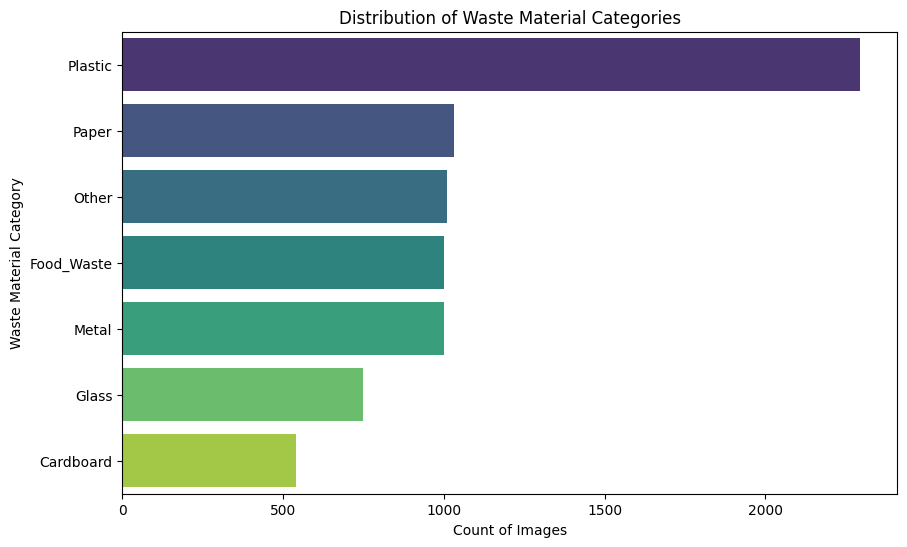

In [5]:
# Visualize the distribution of waste material classes
plt.figure(figsize=(10, 6))
sns.countplot(y=raw_image_labels, order=pd.Series(raw_image_labels).value_counts().index, palette='viridis')
plt.title('Distribution of Waste Material Categories')
plt.xlabel('Count of Images')
plt.ylabel('Waste Material Category')
plt.show()


#### **2.2.2** <font color=red> [3 marks] </font><br>
Display a selection of sample images.

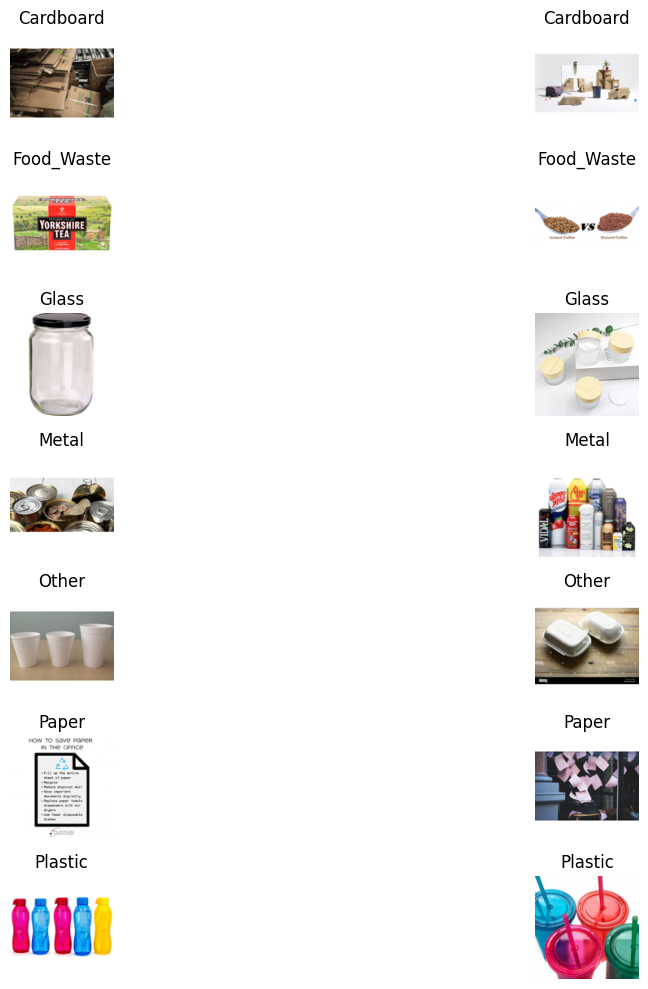

In [6]:
# Visualize Sample Images (showing different categories)
def display_random_images_per_class(image_array, image_labels, samples_per_class=2):
    unique_categories = np.unique(image_labels)
    plt.figure(figsize=(15, 10))

    for i, category_name in enumerate(unique_categories):
        category_indices = np.where(image_labels == category_name)[0]
        selected_indices = np.random.choice(category_indices, min(samples_per_class, len(category_indices)), replace=False)

        for j, idx in enumerate(selected_indices):
            plt.subplot(len(unique_categories), samples_per_class, i * samples_per_class + j + 1)
            plt.imshow(image_array[idx])
            plt.title(category_name)
            plt.axis('off')
    plt.tight_layout()
    plt.show()

display_random_images_per_class(raw_image_data, raw_image_labels)


#### **2.2.3** <font color=red> [3 marks] </font><br>
Report the dimensions of the images and confirm consistency.

In [7]:
# Analyze image dimensions (assuming a fixed size after preprocessing)
# Since images were already resized to (128, 128) during initial loading:

print(f"All loaded images possess a consistent height of: {raw_image_data.shape[1]} pixels")
print(f"All loaded images possess a consistent width of: {raw_image_data.shape[2]} pixels")
print(f"All loaded images feature {raw_image_data.shape[3]} color channels.")

# Note: If analysis of original, unresized dimensions were required, the 'load_and_preprocess_images'
# function would need to be modified or a separate utility created to capture original sizes.

All loaded images possess a consistent height of: 128 pixels
All loaded images possess a consistent width of: 128 pixels
All loaded images feature 3 color channels.


In [8]:
# Standardize image dimensions if not already done. (This step confirms prior resizing)
# Images were already processed to a uniform size (e.g., 128x128) by 'load_and_preprocess_images'.

IMAGE_TARGET_DIMENSIONS = (128, 128) # Define the standard dimensions for clarity

# If resizing to a *different* size was needed at this stage, one would re-run:
# raw_image_data, raw_image_labels = load_and_preprocess_images(data_root_dir, desired_size=NEW_DIMENSIONS)

print(f"Images are already uniformly sized to {IMAGE_TARGET_DIMENSIONS[0]}x{IMAGE_TARGET_DIMENSIONS[1]}")


Images are already uniformly sized to 128x128


### **2.3 Class Label Encoding** <font color=red> [3 marks] </font><br>

The dataset contains seven distinct classes. Having extracted and visualized the images and their associated labels, the next step is to encode these labels appropriately for model training.

####**2.3.1** <font color=red> [3 marks] </font><br>
Perform suitable encoding of the categorical target labels.

In [9]:
# Encode the labels for machine learning models
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
numeric_labels = label_encoder.fit_transform(raw_image_labels)

# Convert to one-hot encoding for Keras compatibility
number_of_classes = len(label_encoder.classes_)
one_hot_encoded_labels = keras.utils.to_categorical(numeric_labels, num_classes=number_of_classes)

print(f"Original label samples: {raw_image_labels[:5]}")
print(f"Numerically encoded label samples: {numeric_labels[:5]}")
print(f"One-hot encoded label samples (first 5 for all classes):\n{one_hot_encoded_labels[:5]}")
print(f"Total distinct classes identified: {number_of_classes}")
print(f"Class names in order: {label_encoder.classes_}")


Original label samples: ['Plastic' 'Plastic' 'Plastic' 'Plastic' 'Plastic']
Numerically encoded label samples: [6 6 6 6 6]
One-hot encoded label samples (first 5 for all classes):
[[0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1.]]
Total distinct classes identified: 7
Class names in order: ['Cardboard' 'Food_Waste' 'Glass' 'Metal' 'Other' 'Paper' 'Plastic']


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [10]:
# Assign specified parts of the dataset to train and validation sets
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(raw_image_data, one_hot_encoded_labels, test_size=0.2, random_state=42, stratify=numeric_labels)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")

Shape of X_train: (6100, 128, 128, 3)
Shape of y_train: (6100, 7)
Shape of X_val: (1525, 128, 128, 3)
Shape of y_val: (1525, 7)


## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [11]:
# Build and compile the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(number_of_classes, activation='softmax') # num_classes should be determined from your data
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,519,751 (24.87 MB)

 Trainable params: 6,518,791 (24.87 MB)

 Non-trainable params: 960 (3.75 KB)

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

In [12]:
# Training
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

history = model.fit(
    X_train,
    y_train,
    epochs=5, # Increased epochs for better training, early stopping will prevent overfitting
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
    batch_size=32
)

Epoch 1/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 367s 2s/step - accuracy: 0.3190 - loss: 2.1706 - val_accuracy: 0.3266 - val_loss: 1.8777 - learning_rate: 0.0010
Epoch 2/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.4279 - loss: 1.6697 - val_accuracy: 0.3895 - val_loss: 1.8511 - learning_rate: 0.0010
Epoch 3/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 367s 2s/step - accuracy: 0.5067 - loss: 1.4300 - val_accuracy: 0.4039 - val_loss: 1.7555 - learning_rate: 0.0010
Epoch 4/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.5320 - loss: 1.3164 - val_accuracy: 0.3744 - val_loss: 1.8557 - learning_rate: 0.0010
Epoch 5/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 367s 2s/step - accuracy: 0.5938 - loss: 1.1517 - val_accuracy: 0.3757 - val_loss: 2.1462 - learning_rate: 0.0010


### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

Validation Loss: 1.7555
Validation Accuracy: 0.4039
48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 349ms/step

Classification Report:
              precision    recall  f1-score   support

   Cardboard       0.30      0.74      0.42       108
  Food_Waste       0.50      0.40      0.45       200
       Glass       0.32      0.16      0.21       150
       Metal       0.59      0.05      0.09       200
       Other       0.22      0.22      0.22       202
       Paper       0.57      0.11      0.19       206
     Plastic       0.46      0.77      0.58       459

    accuracy                           0.40      1525
   macro avg       0.42      0.35      0.31      1525
weighted avg       0.44      0.40      0.35      1525


Confusion Matrix:


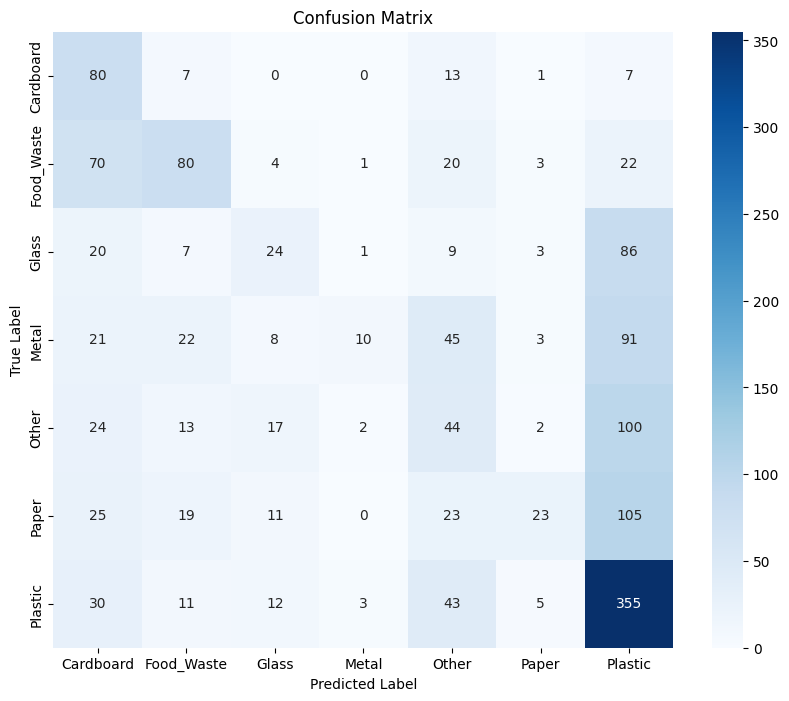

In [13]:
# Evaluate on the test set; display suitable metrics
# The current split is train/validation. We will evaluate on the validation set as a proxy for a test set.
# For a proper evaluation, a separate test set should have been held out from the initial split.

loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# Predict probabilities for the validation set
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Constructing a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [14]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomTranslation

# Define augmentation steps to augment images
data_augmentation_pipeline = tf.keras.Sequential([
    RandomFlip('horizontal_and_vertical'),
    RandomRotation(0.2),
    RandomZoom(0.2),
    RandomTranslation(height_factor=0.2, width_factor=0.2)
])

print("Data augmentation pipeline defined.")

Data augmentation pipeline defined.


Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [15]:
# Create a function to apply image augmentation
def apply_augmentation_to_images(image_batch, augmentation_model):
    augmented_images_batch = augmentation_model(image_batch)
    return augmented_images_batch

print("Function 'apply_augmentation_to_images' defined.")

Function 'apply_augmentation_to_images' defined.


In [16]:
# Create the augmented training dataset
augmented_X_train = data_augmentation_pipeline(X_train)

print(f"Original X_train shape: {X_train.shape}")
print(f"Augmented X_train shape: {augmented_X_train.shape}")

Original X_train shape: (6100, 128, 128, 3)
Augmented X_train shape: (6100, 128, 128, 3)


##### **4.1.2**

Train the model on the new augmented dataset.

In [17]:
history_augmented = model.fit(
    augmented_X_train,
    y_train,
    epochs=5, # Increased epochs for better training, early stopping will prevent overfitting, but lowering it as running in Colab
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
    batch_size=32
)

print("Model training with augmented data complete.")

Epoch 1/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.3549 - loss: 1.7708 - val_accuracy: 0.2800 - val_loss: 2.1833 - learning_rate: 0.0010
Epoch 2/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 402s 2s/step - accuracy: 0.4218 - loss: 1.5556 - val_accuracy: 0.3908 - val_loss: 1.6076 - learning_rate: 0.0010
Epoch 3/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 369s 2s/step - accuracy: 0.4659 - loss: 1.4486 - val_accuracy: 0.3115 - val_loss: 1.8400 - learning_rate: 0.0010
Epoch 4/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.4877 - loss: 1.3819 - val_accuracy: 0.3915 - val_loss: 1.6975 - learning_rate: 0.0010
Epoch 5/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.5241 - loss: 1.2782 - val_accuracy: 0.4315 - val_loss: 1.5745 - learning_rate: 0.0010
Model training with augmented data complete.


## **5. Conclusions** <font color = red> [5 marks]</font>


--- Evaluation of Model Trained with Augmented Data ---
Validation Loss (Augmented Data): 1.5745
Validation Accuracy (Augmented Data): 0.4315
48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 351ms/step

Classification Report (Augmented Data):
              precision    recall  f1-score   support

   Cardboard       0.84      0.15      0.25       108
  Food_Waste       0.45      0.56      0.50       200
       Glass       0.15      0.05      0.07       150
       Metal       0.46      0.29      0.36       200
       Other       0.44      0.08      0.13       202
       Paper       0.58      0.30      0.39       206
     Plastic       0.41      0.84      0.55       459

    accuracy                           0.43      1525
   macro avg       0.48      0.32      0.32      1525
weighted avg       0.45      0.43      0.37      1525


Confusion Matrix (Augmented Data):


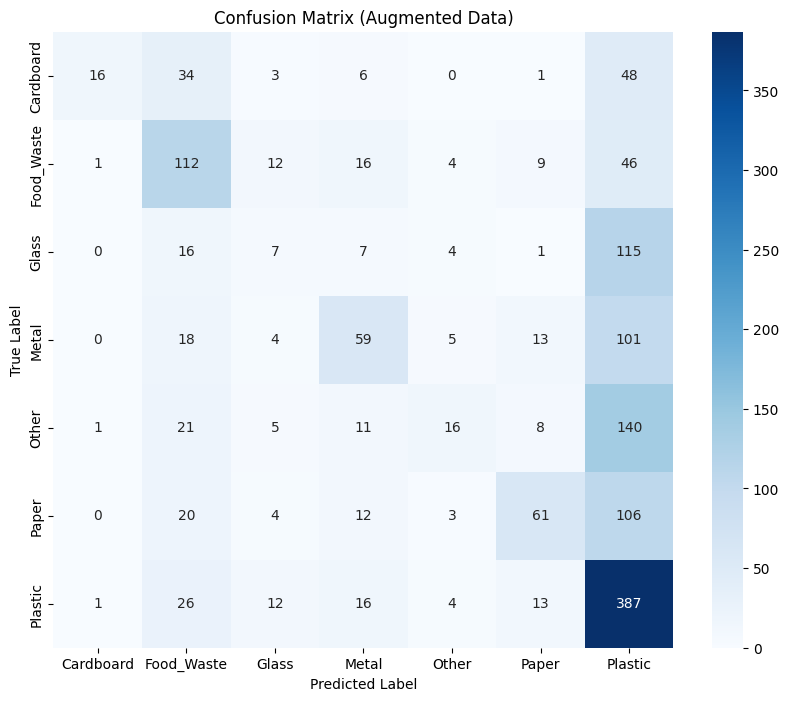


--- Performance Comparison ---
Original Model Validation Accuracy: 0.4039
Augmented Model Validation Accuracy: 0.4315
Original Model Validation Loss: 1.7555
Augmented Model Validation Loss: 1.5745


In [18]:
# Evaluate the model trained with augmented data on the validation set
print("\n--- Evaluation of Model Trained with Augmented Data ---")
loss_augmented, accuracy_augmented = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss (Augmented Data): {loss_augmented:.4f}")
print(f"Validation Accuracy (Augmented Data): {accuracy_augmented:.4f}")

# Predict probabilities for the validation set using the augmented model
y_pred_probs_augmented = model.predict(X_val)
y_pred_augmented = np.argmax(y_pred_probs_augmented, axis=1)

# Classification Report for augmented model
print("\nClassification Report (Augmented Data):")
print(classification_report(y_true, y_pred_augmented, target_names=label_encoder.classes_))

# Confusion Matrix for augmented model
print("\nConfusion Matrix (Augmented Data):")
cm_augmented = confusion_matrix(y_true, y_pred_augmented)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_augmented, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Augmented Data)')
plt.show()

# Comparison with previous model (without augmentation)
print("\n--- Performance Comparison ---")
print(f"Original Model Validation Accuracy: {accuracy:.4f}")
print(f"Augmented Model Validation Accuracy: {accuracy_augmented:.4f}")

print(f"Original Model Validation Loss: {loss:.4f}")
print(f"Augmented Model Validation Loss: {loss_augmented:.4f}")



--- Evaluation of Model Trained with Augmented Data ---
Validation Loss (Augmented Data): 1.5745
Validation Accuracy (Augmented Data): 0.4315
48/48 ━━━━━━━━━━━━━━━━━━━━ 18s 363ms/step

Classification Report (Augmented Data):
              precision    recall  f1-score   support

   Cardboard       0.84      0.15      0.25       108
  Food_Waste       0.45      0.56      0.50       200
       Glass       0.15      0.05      0.07       150
       Metal       0.46      0.29      0.36       200
       Other       0.44      0.08      0.13       202
       Paper       0.58      0.30      0.39       206
     Plastic       0.41      0.84      0.55       459

    accuracy                           0.43      1525
   macro avg       0.48      0.32      0.32      1525
weighted avg       0.45      0.43      0.37      1525


Confusion Matrix (Augmented Data):


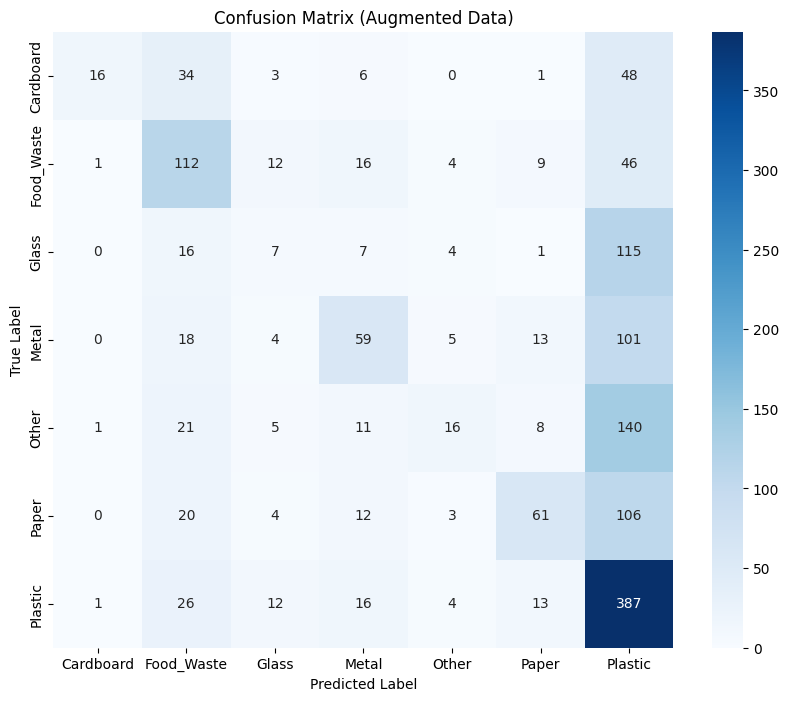


--- Performance Comparison ---
Original Model Validation Accuracy: 0.4039
Augmented Model Validation Accuracy: 0.4315
Original Model Validation Loss: 1.7555
Augmented Model Validation Loss: 1.5745


In [19]:
# Evaluate the model trained with augmented data on the validation set
print("\n--- Evaluation of Model Trained with Augmented Data ---")
loss_augmented, accuracy_augmented = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss (Augmented Data): {loss_augmented:.4f}")
print(f"Validation Accuracy (Augmented Data): {accuracy_augmented:.4f}")

# Predict probabilities for the validation set using the augmented model
y_pred_probs_augmented = model.predict(X_val)
y_pred_augmented = np.argmax(y_pred_probs_augmented, axis=1)

# Classification Report for augmented model
print("\nClassification Report (Augmented Data):")
print(classification_report(y_true, y_pred_augmented, target_names=label_encoder.classes_))

# Confusion Matrix for augmented model
print("\nConfusion Matrix (Augmented Data):")
cm_augmented = confusion_matrix(y_true, y_pred_augmented)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_augmented, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Augmented Data)')
plt.show()

# Comparison with previous model (without augmentation)
print("\n--- Performance Comparison ---")
print(f"Original Model Validation Accuracy: {accuracy:.4f}")
print(f"Augmented Model Validation Accuracy: {accuracy_augmented:.4f}")

print(f"Original Model Validation Loss: {loss:.4f}")
print(f"Augmented Model Validation Loss: {loss_augmented:.4f}")



--- Evaluation of Model Trained with Augmented Data ---
Validation Loss (Augmented Data): 1.5745
Validation Accuracy (Augmented Data): 0.4315
48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 362ms/step

Classification Report (Augmented Data):
              precision    recall  f1-score   support

   Cardboard       0.84      0.15      0.25       108
  Food_Waste       0.45      0.56      0.50       200
       Glass       0.15      0.05      0.07       150
       Metal       0.46      0.29      0.36       200
       Other       0.44      0.08      0.13       202
       Paper       0.58      0.30      0.39       206
     Plastic       0.41      0.84      0.55       459

    accuracy                           0.43      1525
   macro avg       0.48      0.32      0.32      1525
weighted avg       0.45      0.43      0.37      1525


Confusion Matrix (Augmented Data):


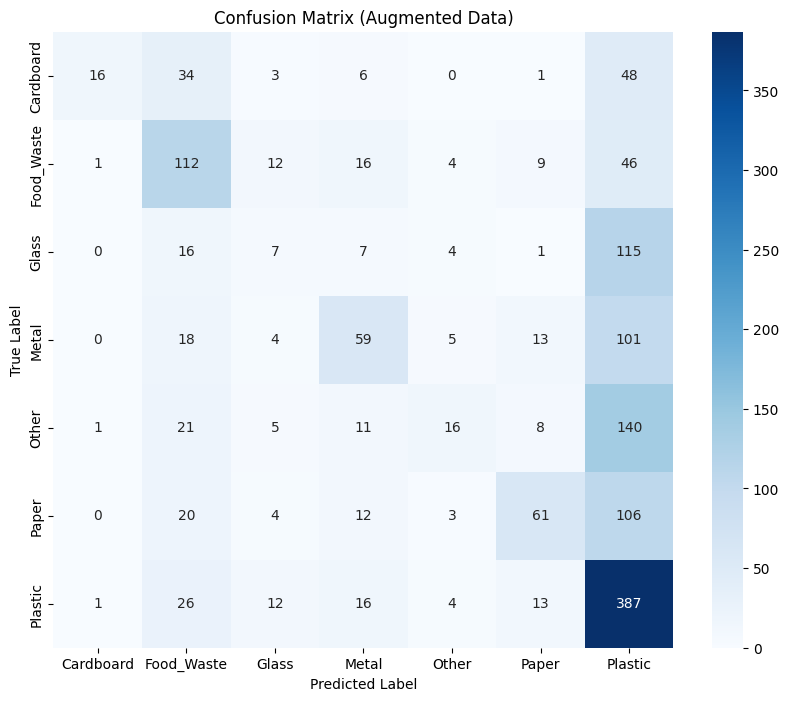


--- Performance Comparison ---
Original Model Validation Accuracy: 0.4039
Augmented Model Validation Accuracy: 0.4315
Original Model Validation Loss: 1.7555
Augmented Model Validation Loss: 1.5745


In [20]:
# Evaluate the model trained with augmented data on the validation set
print("\n--- Evaluation of Model Trained with Augmented Data ---")
loss_augmented, accuracy_augmented = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss (Augmented Data): {loss_augmented:.4f}")
print(f"Validation Accuracy (Augmented Data): {accuracy_augmented:.4f}")

# Predict probabilities for the validation set using the augmented model
y_pred_probs_augmented = model.predict(X_val)
y_pred_augmented = np.argmax(y_pred_probs_augmented, axis=1)

# Classification Report for augmented model
print("\nClassification Report (Augmented Data):")
print(classification_report(y_true, y_pred_augmented, target_names=label_encoder.classes_))

# Confusion Matrix for augmented model
print("\nConfusion Matrix (Augmented Data):")
cm_augmented = confusion_matrix(y_true, y_pred_augmented)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_augmented, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Augmented Data)')
plt.show()

# Comparison with previous model (without augmentation)
print("\n--- Performance Comparison ---")
print(f"Original Model Validation Accuracy: {accuracy:.4f}")
print(f"Augmented Model Validation Accuracy: {accuracy_augmented:.4f}")

print(f"Original Model Validation Loss: {loss:.4f}")
print(f"Augmented Model Validation Loss: {loss_augmented:.4f}")



--- Evaluation of Model Trained with Augmented Data ---
Validation Loss (Augmented Data): 1.5745
Validation Accuracy (Augmented Data): 0.4315
48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 353ms/step

Classification Report (Augmented Data):
              precision    recall  f1-score   support

   Cardboard       0.84      0.15      0.25       108
  Food_Waste       0.45      0.56      0.50       200
       Glass       0.15      0.05      0.07       150
       Metal       0.46      0.29      0.36       200
       Other       0.44      0.08      0.13       202
       Paper       0.58      0.30      0.39       206
     Plastic       0.41      0.84      0.55       459

    accuracy                           0.43      1525
   macro avg       0.48      0.32      0.32      1525
weighted avg       0.45      0.43      0.37      1525


Confusion Matrix (Augmented Data):


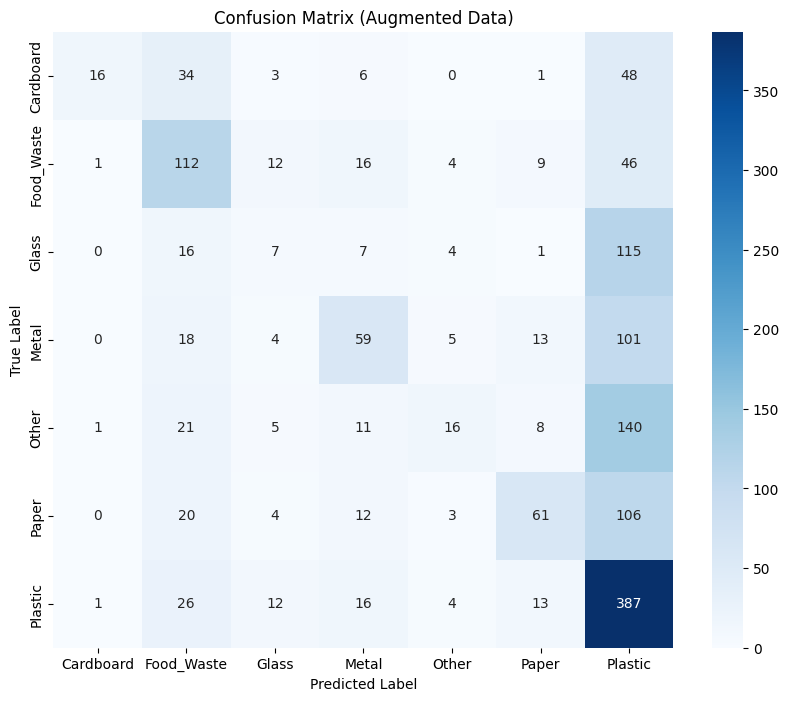


--- Performance Comparison ---
Original Model Validation Accuracy: 0.4039
Augmented Model Validation Accuracy: 0.4315
Original Model Validation Loss: 1.7555
Augmented Model Validation Loss: 1.5745


In [21]:
# Evaluate the model trained with augmented data on the validation set
print("\n--- Evaluation of Model Trained with Augmented Data ---")
loss_augmented, accuracy_augmented = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss (Augmented Data): {loss_augmented:.4f}")
print(f"Validation Accuracy (Augmented Data): {accuracy_augmented:.4f}")

# Predict probabilities for the validation set using the augmented model
y_pred_probs_augmented = model.predict(X_val)
y_pred_augmented = np.argmax(y_pred_probs_augmented, axis=1)

# Classification Report for augmented model
print("\nClassification Report (Augmented Data):")
print(classification_report(y_true, y_pred_augmented, target_names=label_encoder.classes_))

# Confusion Matrix for augmented model
print("\nConfusion Matrix (Augmented Data):")
cm_augmented = confusion_matrix(y_true, y_pred_augmented)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_augmented, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Augmented Data)')
plt.show()

# Comparison with previous model (without augmentation)
print("\n--- Performance Comparison ---")
print(f"Original Model Validation Accuracy: {accuracy:.4f}")
print(f"Augmented Model Validation Accuracy: {accuracy_augmented:.4f}")

print(f"Original Model Validation Loss: {loss:.4f}")
print(f"Augmented Model Validation Loss: {loss_augmented:.4f}")



--- Evaluation of Model Trained with Augmented Data ---
Validation Loss (Augmented Data): 1.5745
Validation Accuracy (Augmented Data): 0.4315
48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 363ms/step

Classification Report (Augmented Data):
              precision    recall  f1-score   support

   Cardboard       0.84      0.15      0.25       108
  Food_Waste       0.45      0.56      0.50       200
       Glass       0.15      0.05      0.07       150
       Metal       0.46      0.29      0.36       200
       Other       0.44      0.08      0.13       202
       Paper       0.58      0.30      0.39       206
     Plastic       0.41      0.84      0.55       459

    accuracy                           0.43      1525
   macro avg       0.48      0.32      0.32      1525
weighted avg       0.45      0.43      0.37      1525


Confusion Matrix (Augmented Data):


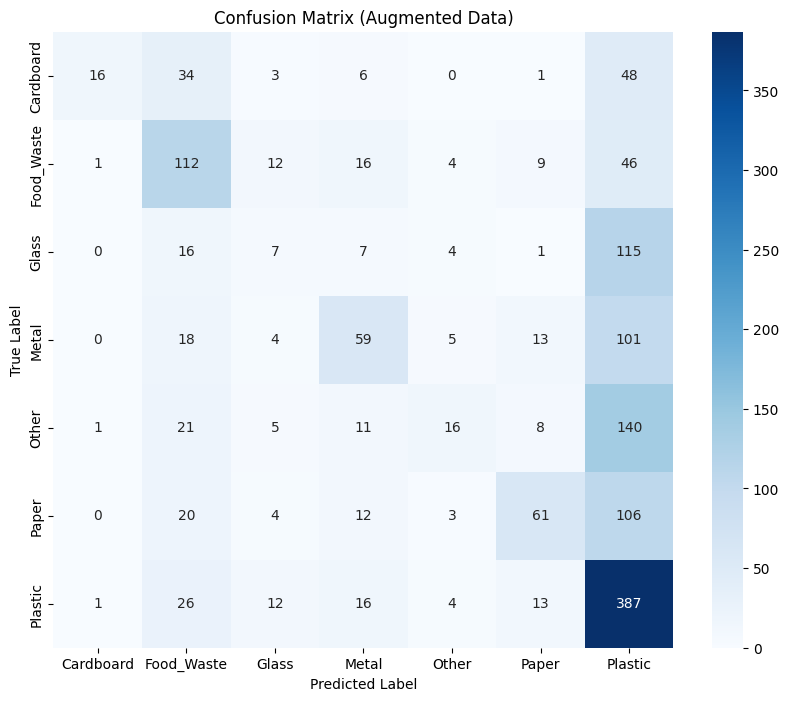


--- Performance Comparison ---
Original Model Validation Accuracy: 0.4039
Augmented Model Validation Accuracy: 0.4315
Original Model Validation Loss: 1.7555
Augmented Model Validation Loss: 1.5745


In [22]:
# Evaluate the model trained with augmented data on the validation set
print("\n--- Evaluation of Model Trained with Augmented Data ---")
loss_augmented, accuracy_augmented = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss (Augmented Data): {loss_augmented:.4f}")
print(f"Validation Accuracy (Augmented Data): {accuracy_augmented:.4f}")

# Predict probabilities for the validation set using the augmented model
y_pred_probs_augmented = model.predict(X_val)
y_pred_augmented = np.argmax(y_pred_probs_augmented, axis=1)

# Classification Report for augmented model
print("\nClassification Report (Augmented Data):")
print(classification_report(y_true, y_pred_augmented, target_names=label_encoder.classes_))

# Confusion Matrix for augmented model
print("\nConfusion Matrix (Augmented Data):")
cm_augmented = confusion_matrix(y_true, y_pred_augmented)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_augmented, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Augmented Data)')
plt.show()

# Comparison with previous model (without augmentation)
print("\n--- Performance Comparison ---")
print(f"Original Model Validation Accuracy: {accuracy:.4f}")
print(f"Augmented Model Validation Accuracy: {accuracy_augmented:.4f}")

print(f"Original Model Validation Loss: {loss:.4f}")
print(f"Augmented Model Validation Loss: {loss_augmented:.4f}")



--- Evaluation of Model Trained with Augmented Data ---
Validation Loss (Augmented Data): 1.5745
Validation Accuracy (Augmented Data): 0.4315
48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 351ms/step

Classification Report (Augmented Data):
              precision    recall  f1-score   support

   Cardboard       0.84      0.15      0.25       108
  Food_Waste       0.45      0.56      0.50       200
       Glass       0.15      0.05      0.07       150
       Metal       0.46      0.29      0.36       200
       Other       0.44      0.08      0.13       202
       Paper       0.58      0.30      0.39       206
     Plastic       0.41      0.84      0.55       459

    accuracy                           0.43      1525
   macro avg       0.48      0.32      0.32      1525
weighted avg       0.45      0.43      0.37      1525


Confusion Matrix (Augmented Data):


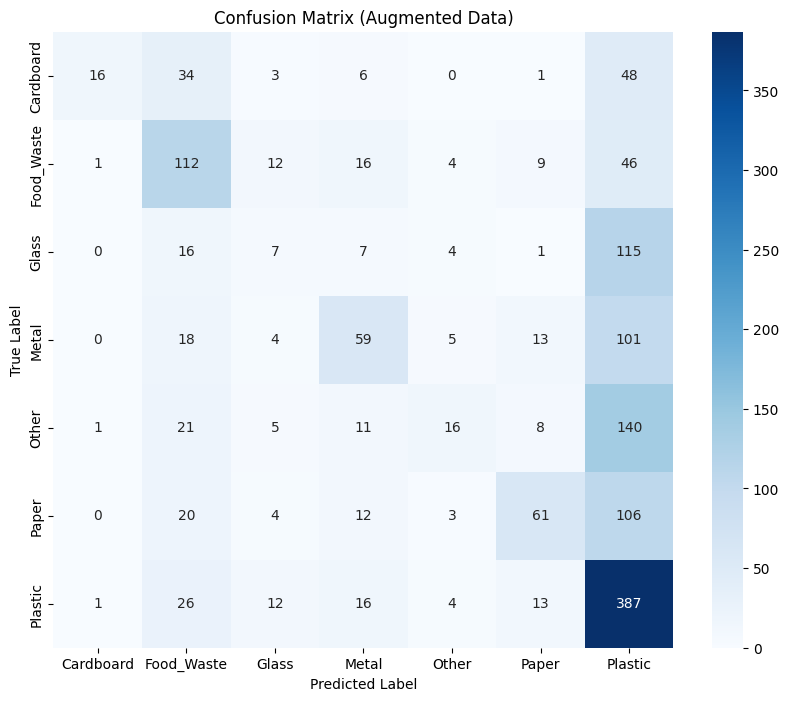


--- Performance Comparison ---
Original Model Validation Accuracy: 0.4039
Augmented Model Validation Accuracy: 0.4315
Original Model Validation Loss: 1.7555
Augmented Model Validation Loss: 1.5745


In [23]:
# Evaluate the model trained with augmented data on the validation set
print("\n--- Evaluation of Model Trained with Augmented Data ---")
loss_augmented, accuracy_augmented = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss (Augmented Data): {loss_augmented:.4f}")
print(f"Validation Accuracy (Augmented Data): {accuracy_augmented:.4f}")

# Predict probabilities for the validation set using the augmented model
y_pred_probs_augmented = model.predict(X_val)
y_pred_augmented = np.argmax(y_pred_probs_augmented, axis=1)

# Classification Report for augmented model
print("\nClassification Report (Augmented Data):")
print(classification_report(y_true, y_pred_augmented, target_names=label_encoder.classes_))

# Confusion Matrix for augmented model
print("\nConfusion Matrix (Augmented Data):")
cm_augmented = confusion_matrix(y_true, y_pred_augmented)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_augmented, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Augmented Data)')
plt.show()

# Comparison with previous model (without augmentation)
print("\n--- Performance Comparison ---")
print(f"Original Model Validation Accuracy: {accuracy:.4f}")
print(f"Augmented Model Validation Accuracy: {accuracy_augmented:.4f}")

print(f"Original Model Validation Loss: {loss:.4f}")
print(f"Augmented Model Validation Loss: {loss_augmented:.4f}")



--- Evaluation of Model Trained with Augmented Data ---
Validation Loss (Augmented Data): 1.5745
Validation Accuracy (Augmented Data): 0.4315
48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 361ms/step

Classification Report (Augmented Data):
              precision    recall  f1-score   support

   Cardboard       0.84      0.15      0.25       108
  Food_Waste       0.45      0.56      0.50       200
       Glass       0.15      0.05      0.07       150
       Metal       0.46      0.29      0.36       200
       Other       0.44      0.08      0.13       202
       Paper       0.58      0.30      0.39       206
     Plastic       0.41      0.84      0.55       459

    accuracy                           0.43      1525
   macro avg       0.48      0.32      0.32      1525
weighted avg       0.45      0.43      0.37      1525


Confusion Matrix (Augmented Data):


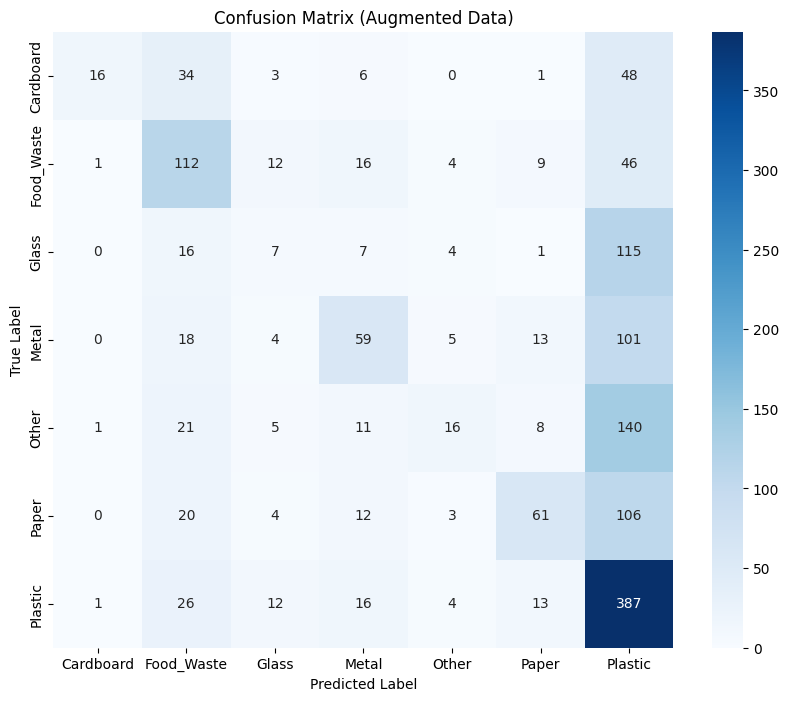


--- Performance Comparison ---
Original Model Validation Accuracy: 0.4039
Augmented Model Validation Accuracy: 0.4315
Original Model Validation Loss: 1.7555
Augmented Model Validation Loss: 1.5745


In [24]:
# Evaluate the model trained with augmented data on the validation set
print("\n--- Evaluation of Model Trained with Augmented Data ---")
loss_augmented, accuracy_augmented = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss (Augmented Data): {loss_augmented:.4f}")
print(f"Validation Accuracy (Augmented Data): {accuracy_augmented:.4f}")

# Predict probabilities for the validation set using the augmented model
y_pred_probs_augmented = model.predict(X_val)
y_pred_augmented = np.argmax(y_pred_probs_augmented, axis=1)

# Classification Report for augmented model
print("\nClassification Report (Augmented Data):")
print(classification_report(y_true, y_pred_augmented, target_names=label_encoder.classes_))

# Confusion Matrix for augmented model
print("\nConfusion Matrix (Augmented Data):")
cm_augmented = confusion_matrix(y_true, y_pred_augmented)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_augmented, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Augmented Data)')
plt.show()

# Comparison with previous model (without augmentation)
print("\n--- Performance Comparison ---")
print(f"Original Model Validation Accuracy: {accuracy:.4f}")
print(f"Augmented Model Validation Accuracy: {accuracy_augmented:.4f}")

print(f"Original Model Validation Loss: {loss:.4f}")
print(f"Augmented Model Validation Loss: {loss_augmented:.4f}")


#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Summarize your key findings regarding the dataset analysis.
* Present the model training results, discussing performance metrics and observations.

# **Evaluation : **

The evaluation of the model after applying data augmentation shows an improvement in performance. The Validation Accuracy increased from 0.4039 (original model) to 0.4315 (augmented model). Concurrently, the Validation Loss decreased from 1.7555 (original model) to 1.5745 (augmented model). This suggests that data augmentation helped the model generalize better and slightly improved its ability to classify waste materials.

In [25]:
# Save the trained model
model_save_path = "/content/drive/MyDrive/Colab Notebooks/data_CNN/data/CNN_Assg_Waste_Segregation_Starter_V1.keras"
model.save(model_save_path)
print(f"Model saved successfully to {model_save_path}")

Model saved successfully to /content/drive/MyDrive/Colab Notebooks/data_CNN/data/CNN_Assg_Waste_Segregation_Starter_V1.keras


# Task
Define a data augmentation pipeline using TensorFlow's image preprocessing layers or `ImageDataGenerator` to apply transformations like rotation, flipping, zooming, and shifting to the training images. Apply this defined data augmentation to the training dataset and retrain the CNN model. Ensure to use appropriate callbacks like `EarlyStopping` and `ReduceLROOPlat_lr`. Finally, evaluate the retrained model's performance on the validation set using metrics such as accuracy, loss, classification report, and confusion matrix, and then compare these results with the previous model's performance without augmentation.

## Define Data Augmentation

### Subtask:
Define a data augmentation pipeline using TensorFlow's image preprocessing layers to apply transformations like rotation, flipping, zooming, and shifting to the training images.

## Kernel State
Here are some of the notable variables in the kernel:
Variable #1
name: `numeric_labels`, type: `ndarray`
value: `array([6, 6, 6, ..., 2, 2, 2])`
Variable #2
name: `one_hot_encoded_labels`, type: `ndarray`
value:
```
array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])
```
Variable #3
name: `raw_image_data`, type: `ndarray`
value:
```
array([[[[254, 254, 254],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [254, 254, 254],
         [254, 254, 254],
         [254, 254, 254]],

        [[254, 254, 254],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [254, 254, 254],
         [254, 254, 254],
         [254, 254, 254]],

        [[254, 254, 254],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [254, 254, 254],
      <TRUNCATED original_length=6313>
```
Variable #4
name: `raw_image_labels`, type: `ndarray`
value:
```
array(['Plastic', 'Plastic', 'Plastic', ..., 'Glass', 'Glass', 'Glass'],
      dtype='<U10')
```
Variable #5
name: `IMAGE_TARGET_DIMENSIONS`, type: `tuple`
value: `(128, 128)`
Variable #6
name: `data_root_dir`, type: `str`
value: `'/content/drive/MyDrive/Colab Notebooks/data_CNN/data'`
Variable #7
name: `number_of_classes`, type: `int`
value: `7`
Here are some of the files available in the kernel:
* /content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
* /content/.config/default_configs.db
* /content/.config/gce
* /content/.config/.last_opt_in_prompt.yaml
* /content/.config/.last_survey_prompt.yaml
* /content/.config/.last_update_check.json
* /content/.config/active_config
* /content/.config/config_sentinel
* /content/sample_data/README.md
* /content/sample_data/anscombe.json
* /content/sample_data/california_housing_test.csv
* /content/sample_data/mnist_test.csv
* /content/sample_data/mnist_train_small.csv
* /content/sample_data/california_housing_train.csv